# Test of Gaussian Process Inverse Methods
Newton Schulz inverse vs. Numpy Inverse vs. Cholseky

In [9]:
import numpy as np
import os 
import matplotlib.pyplot as plt
import sys
from pathlib import Path
import GP
REPO_ROOT = Path.cwd().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from functions import Newton_Shulz

(20,)
(20,)
Using provided initial guess for Newton-Schulz
Newton-Schulz converged at iteration 30 (error: 7.509506e-10 < 1.00e-08)
Newton_Shulz took 0.0022 seconds to execute.


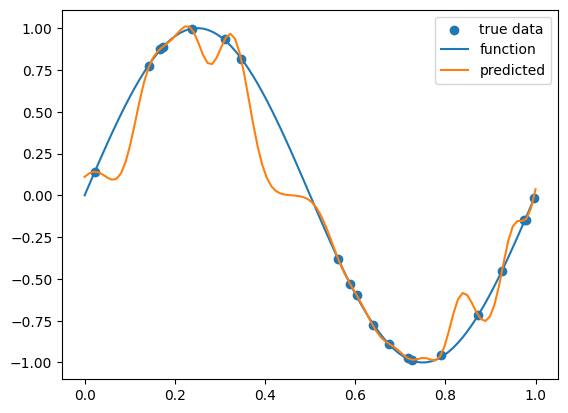

In [ ]:
# make somme data
n = 20
sig = 0.01
x = np.random.rand(n)
# print(x)
# y = np.sin(x* 2*np.pi) + sig*np.random.randn(n)

print(x.shape)
print(y.shape)

xth = np.linspace(0,1, 100)
yth = np.sin(xth * 2*np.pi)

# create a gaussian process object
gauss = GP.GPR(n, 1, "RBF", sig, use_ns=True, verbose=True)
# fit the gaussian process to the given data, for some sigma_f and l
gauss.fit(np.array([x]), y, theta=np.array([10, 1e-3])) # changing the hyperparameters gives you different fits
# new_x = np.random.rand(5)
new_y = gauss.predict_aft_K(xth)

fig = plt.figure()
plt.scatter(x, y, label="true data")
plt.plot(xth, yth, label="function")
plt.plot(xth, new_y, label="predicted")

plt.legend()

Running gradient descent with theta0 = [1 1]
Using a stopping condition of ||nabla f||^2 < 1e-05
Using a step size of 1e-05
Using provided initial guess for Newton-Schulz
Newton_Shulz exceeded the max number of iterations and has error 4.5641470487691925e-07
Newton_Shulz took 0.0509 seconds to execute.
Iteration 0
theta =  [1 1]
log liklihood = -1701.3845386657258
Iteration 1
theta =  [41.08010354  0.97948466]
Using provided initial guess for Newton-Schulz
Newton_Shulz exceeded the max number of iterations and has error 1.3499878957202784
Newton_Shulz took 0.0679 seconds to execute.
log liklihood = -21.961661724161004
Iteration 2
theta =  [80.20795238  0.97826075]
Using provided initial guess for Newton-Schulz
Newton_Shulz exceeded the max number of iterations and has error 17.064047460133164
Newton_Shulz took 0.0731 seconds to execute.
log liklihood = 13.356271401687348
Iteration 3
theta =  [73.42728686  0.97784289]
Using provided initial guess for Newton-Schulz
Newton_Shulz exceeded 

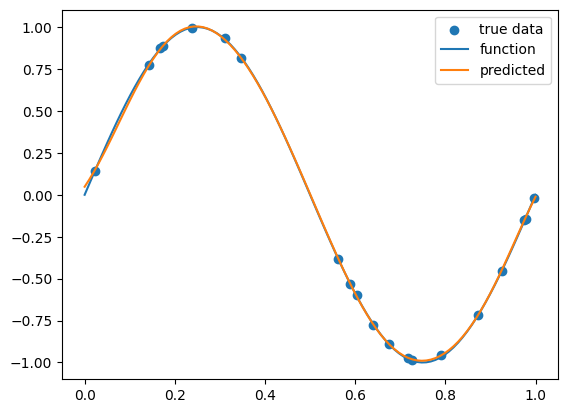

In [15]:
# try optimizing
gauss.grad_dec_theta(np.array([1, 1]), alpha=1e-5)
new_y = gauss.predict_aft_K(xth)

fig = plt.figure()
plt.scatter(x, y, label="true data")
plt.plot(xth, yth, label="function")
plt.plot(xth, new_y, label="predicted")

plt.legend()

In [17]:
# create a gaussian process object
gauss_no_ns = GP.GPR(n, 1, "RBF", sig, use_ns=False, verbose=True)
# fit the gaussian process to the given data, for some sigma_f and l
gauss_no_ns.fit(np.array([x]), y, theta=np.array([10, 1e-3])) # changing the hyperparameters gives you different fits
# new_x = np.random.rand(5)
new_y = gauss_no_ns.predict_aft_K(xth)

Running gradient descent with theta0 = [1 1]
Using a stopping condition of ||nabla f||^2 < 1e-05
Using a step size of 1e-05
Iteration 0
theta =  [1 1]
log liklihood = -1701.3845386603757
Iteration 1
theta =  [41.08010354  0.97948466]
log liklihood = -21.961662430470973
Iteration 2
theta =  [80.20795208  0.9782606 ]
log liklihood = 13.356285007031993
Iteration 3
theta =  [73.42727231  0.97784313]
log liklihood = 10.808471252118267
Iteration 4
theta =  [70.48458712  0.97735294]
log liklihood = 9.49805086432923
Iteration 5
theta =  [69.39300726  0.97682623]
log liklihood = 9.00704778430314
Iteration 6
theta =  [68.98255474  0.97628606]
log liklihood = 8.853887070235281
Iteration 7
theta =  [68.78666381  0.97574097]
log liklihood = 8.81129532711494
Iteration 8
theta =  [68.65425374  0.97519447]
log liklihood = 8.80178707439206
Iteration 9
theta =  [68.54030307  0.97464705]
log liklihood = 8.801966542982719
Iteration 10
theta =  [68.43166511  0.97409933]
log liklihood = 8.804908620028861
It

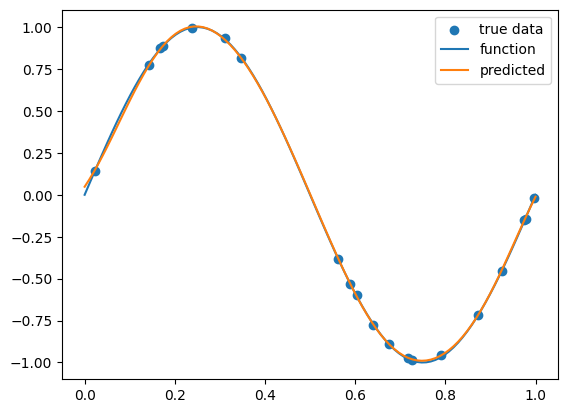

In [18]:
# try optimizing
gauss_no_ns.grad_dec_theta(np.array([1, 1]), alpha=1e-5)
new_y = gauss_no_ns.predict_aft_K(xth)

fig = plt.figure()
plt.scatter(x, y, label="true data")
plt.plot(xth, yth, label="function")
plt.plot(xth, new_y, label="predicted")

plt.legend()